/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_50464/1980537041.py:161: F

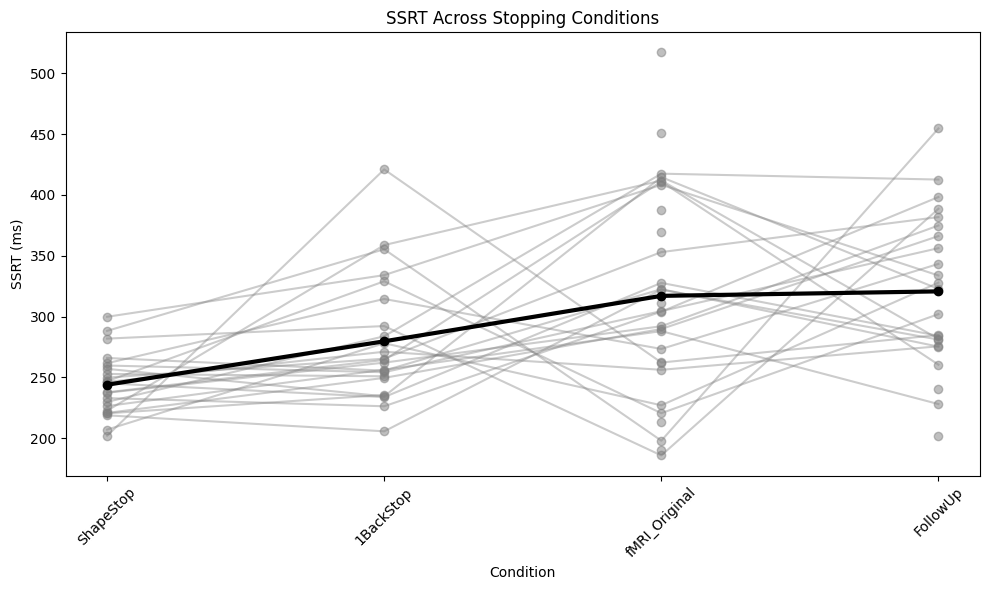

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install openpyxl
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ---------------------------
# 1. Define files and their column mappings
# ---------------------------
files_info = {
    "fMRI_Original": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/BeastfMRIN30.xlsx",
        "subject_col": "SubjID",
        "rt_col": "RT",
        "stop_acc_col": "StopAcc",
        "ssd_col": "SSD",
        "stop_go_col": "Stop1OrNoStop2",
        "go_code": 2,
        "stop_code": 1,
        "go_acc": "GoAcc",
        "stim_col": "Target1NonTarget2TempNonTarget3",
        "stim_map": {1: "Target", 2: "Non-target", 3: "Lure"}
    },
    "FollowUp": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/N23NonFMRIBeast.xlsx",
        "subject_col": "subject_id",
        "rt_col": "RT",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "SS_trial_type",
        "go_code": "go",
        "stop_code": "stop",
        "go_acc": "go_acc",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "1BackStop": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/1BackStoppingN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "stop_trial_type",
        "go_code": "go",
        "go_acc": "go_acc",
        "stop_code": "stop",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "NBackNoStop": {  # no stop trials
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/NBackNoStopN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": None,
        "ssd_col": None,
        "stop_go_col": None,
        "go_code": None,
        "stop_code": None,
        "go_acc": None,
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "ShapeStop": {
    "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/StopNoNBackN23.xlsx",
    "subject_col": "subject_ID",
    "rt_col": "rt",
    "stop_acc_col": "stop_acc",
    "ssd_col": "SS_delay",
    "stop_go_col": "SS_trial_type",
    "go_code": "go",     # <-- strings, not 0/1
    "stop_code": "stop",
    "go_acc": "go_acc",
    "shape_col": "go_stim",
    "shape_map": {"black_circle": "Circle", "black_triangle": "Triangle"}
}
}

# ---------------------------
# 2. SSRT computation function
# ---------------------------
def compute_ssrt(df, stop_go_col, stop_acc_col, ssd_col, rt_col, go_code, stop_code):
    df = df.copy()
    
    # skip if no stop trials (e.g., NBackNoStop)
    if stop_go_col is None or stop_acc_col is None or ssd_col is None:
        return np.nan
    
    # Map stop/go to 1 = stop, 2 = go
    df['stop_trial'] = df[stop_go_col].map({stop_code: 1, go_code: 2})
    go_trials = df[df['stop_trial'] == 2]
    stop_trials = df[df['stop_trial'] == 1]
    
    if len(go_trials) == 0 or len(stop_trials) == 0:
        return np.nan
    
    p_respond = 1 - stop_trials[stop_acc_col].mean()
    go_rts = np.sort(go_trials[rt_col].values)
    n_idx = int(np.ceil(p_respond * len(go_rts))) - 1
    n_idx = max(n_idx, 0)
    nth_rt = go_rts[n_idx]
    mean_ssd = stop_trials[ssd_col].mean()
    
    return nth_rt - mean_ssd

# ---------------------------
# 3. Loop through files and compute SSRT
# ---------------------------
ssrt_list = []

for cond_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace
    
    # Robust subject column detection
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    if subject_col is None:
        raise ValueError(f"Subject column not found in {cond_name} dataset")
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    for subj in df['subject'].unique():
        subj_df = df[df['subject'] == subj]
        try:
            ssrt = compute_ssrt(
                subj_df,
                stop_go_col=info.get('stop_go_col'),
                stop_acc_col=info.get('stop_acc_col'),
                ssd_col=info.get('ssd_col'),
                rt_col=info['rt_col'],
                go_code=info.get('go_code'),
                stop_code=info.get('stop_code')
            )
            ssrt_list.append({"subject": subj, "Condition": cond_name, "SSRT": ssrt})
        except Exception as e:
            print(f"Skipping subject {subj} in {cond_name}: {e}")

ssrt_df = pd.DataFrame(ssrt_list)

# Filter extreme SSRTs
ssrt_df = ssrt_df[(ssrt_df['SSRT'] >= 100) & (ssrt_df['SSRT'] <= 600)]

# ---------------------------
# 4. Plot SSRT across stopping conditions
# ---------------------------
plt.figure(figsize=(10,6))

# Correct order: ShapeStop, 1BackStop, fMRI_Original, FollowUp
condition_order = ["ShapeStop", "1BackStop", "fMRI_Original", "FollowUp"]

# Apply categorical ordering
ssrt_df['Condition'] = pd.Categorical(ssrt_df['Condition'], categories=condition_order, ordered=True)

# Spaghetti plot (each subject)
for sub in ssrt_df['subject'].unique():
    sub_df = ssrt_df[ssrt_df['subject'] == sub].set_index('Condition').reindex(condition_order)
    plt.plot(condition_order, sub_df['SSRT'], color='gray', alpha=0.4)

# Mean line
mean_df = ssrt_df.groupby('Condition')['SSRT'].mean().reindex(condition_order)
plt.plot(condition_order, mean_df, color='black', linewidth=3, marker='o')

# Overlay individual points
for cond in condition_order:
    y_vals = ssrt_df[ssrt_df['Condition'] == cond]['SSRT']
    x_vals = [cond]*len(y_vals)
    plt.scatter(x_vals, y_vals, color='gray', alpha=0.5)

plt.xlabel("Condition")
plt.ylabel("SSRT (ms)")
plt.title("SSRT Across Stopping Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


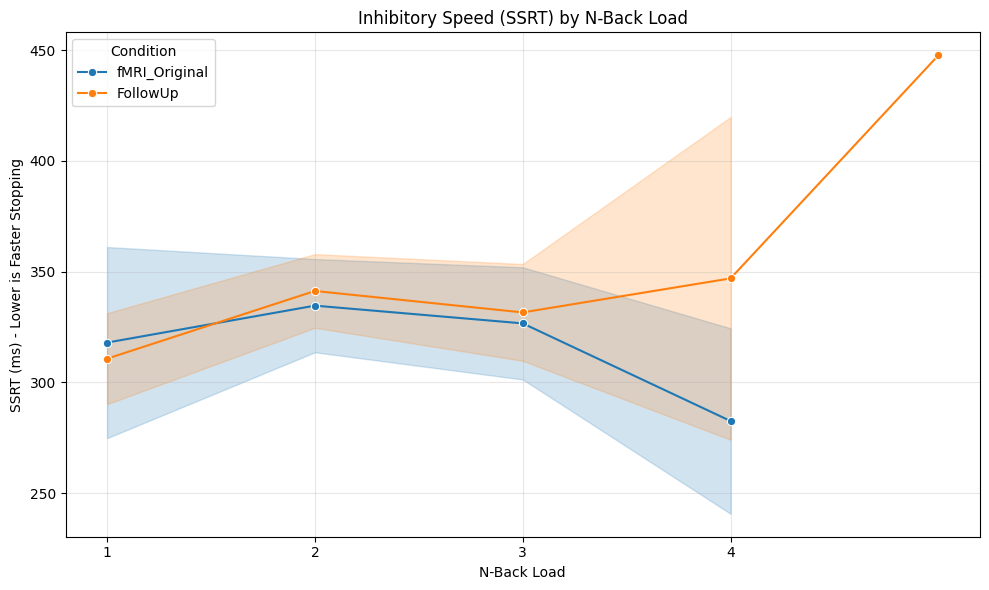

Mean SSRT per Load:
Load
1.0    315.15
2.0    337.55
3.0    328.74
4.0    321.21
5.0    447.75
Name: SSRT, dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------
# SSRT ANALYSIS BY LOAD
# ---------------------------
ssrt_results = []
target_tasks = ["fMRI_Original", "FollowUp"]

for task in target_tasks:
    if task not in files_info: continue
    info = files_info[task]
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()
    
    # 1. Standardize Columns (Consistent with Cell 1)
    subj_col = next((c for c in df.columns if 'subj' in c.lower()), 'subject')
    acc_col = next((c for c in df.columns if 'stop' in c.lower() and 'acc' in c.lower()), None)
    load_col = next((c for c in df.columns if c.lower() == 'load'), 'Load')
    rt_col = info['rt_col']
    ssd_col = info.get('ssd_col')
    
    df.rename(columns={subj_col: 'subject', load_col: 'Load'}, inplace=True)

    # 2. Compute SSRT for each Subject at each Load level
    for (subj, load), subj_load_df in df.groupby(['subject', 'Load']):
        
        # Split into Go and Stop trials
        if 'NoStop1StopSuccess2StopFail3' in df.columns:
            go_trials = subj_load_df[subj_load_df['NoStop1StopSuccess2StopFail3'] == 1]
            stop_trials = subj_load_df[subj_load_df['NoStop1StopSuccess2StopFail3'].isin([2, 3])]
        else:
            go_trials = subj_load_df[subj_load_df['stop_trial_type'] == 'go']
            stop_trials = subj_load_df[subj_load_df['stop_trial_type'] != 'go']

        # Check for sufficient data (need both trial types to compute SSRT)
        if len(go_trials) >= 5 and len(stop_trials) >= 5:
            # Integration Method Calculation
            p_respond = 1 - stop_trials[acc_col].mean()
            go_rts = np.sort(go_trials[rt_col].dropna().values)
            
            # Find the RT corresponding to the probability of responding
            n_idx = int(np.ceil(p_respond * len(go_rts))) - 1
            n_idx = max(0, min(n_idx, len(go_rts) - 1))
            
            ssrt = go_rts[n_idx] - stop_trials[ssd_col].mean()
            
            ssrt_results.append({
                "subject": subj, 
                "Condition": task, 
                "Load": load, 
                "SSRT": ssrt
            })

# 3. Clean and Plot
ssrt_df = pd.DataFrame(ssrt_results)
# Remove outliers (SSRTs outside 50-800ms are usually invalid)
ssrt_df = ssrt_df[(ssrt_df['SSRT'] >= 50) & (ssrt_df['SSRT'] <= 800)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=ssrt_df, x='Load', y='SSRT', hue='Condition', marker='o', errorbar='se')

plt.title("Inhibitory Speed (SSRT) by N-Back Load")
plt.ylabel("SSRT (ms) - Lower is Faster Stopping")
plt.xlabel("N-Back Load")
plt.xticks([1, 2, 3, 4])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean SSRT per Load:")
print(ssrt_df.groupby('Load')['SSRT'].mean().round(2))

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


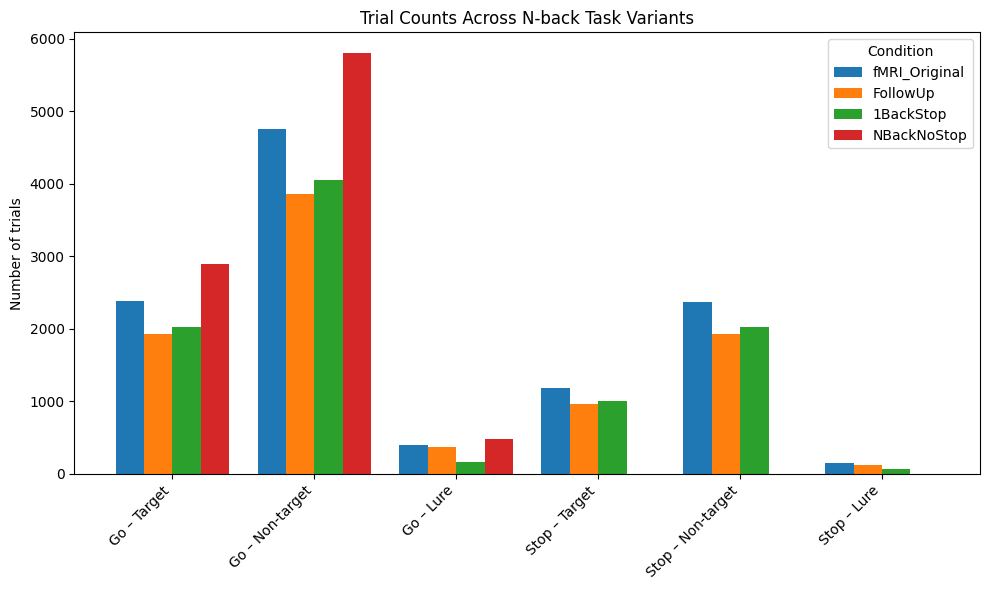

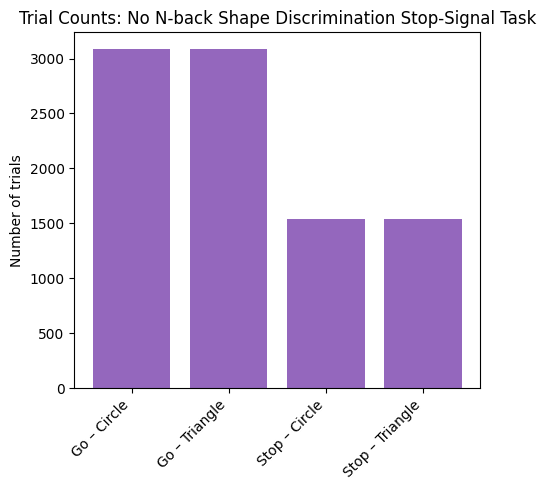

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


            Task   n_go  n_stop  stop_signal_proportion
0  fMRI_Original   7529    3711                0.330160
1       FollowUp   6163    3024                0.329161
2      1BackStop   6236    3102                0.332191
3    NBackNoStop  18749       0                0.000000
4      ShapeStop   6168    3084                0.333333


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


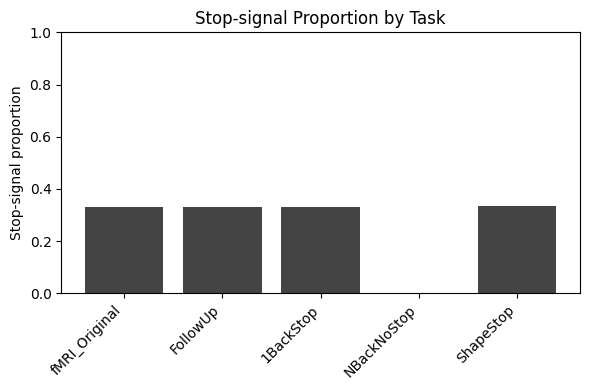

In [3]:
# ---------------------------
# Trial counts per condition x trial type
# ---------------------------

trial_counts_list = []

for task_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # ---- Stimulus label ----
    if task_name == "ShapeStop":
        df['stim_label'] = df[info['shape_col']].map(info['shape_map'])
    else:
        df['stim_label'] = df[info['stim_col']].map(info['stim_map'])

    # ---- Trial type ----
    if info['stop_go_col'] is not None:
        df['trial_type'] = df[info['stop_go_col']].map({info['stop_code']: 'Stop', info['go_code']: 'Go'})
        df['trial_label'] = df['trial_type'] + ' – ' + df['stim_label']
    else:
        df['trial_type'] = 'Go'
        df['trial_label'] = 'Go – ' + df['stim_label']

    # ---- Count trials per label ----
    counts = df.groupby('trial_label').size().reset_index(name='n_trials')
    counts['task'] = task_name
    trial_counts_list.append(counts)

# Combine all tasks
trial_counts = pd.concat(trial_counts_list, ignore_index=True)

# ---------------------------
# 1. Define trial types to include (for N-back)
# ---------------------------
trial_types_order = [
    "Go – Target", "Go – Non-target", "Go – Lure",
    "Stop – Target", "Stop – Non-target", "Stop – Lure"
]

# N-back tasks
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]

# ---------------------------
# 2. Pivot data for grouped bar plot
# ---------------------------
# Filter only N-back tasks
nback_counts = trial_counts[trial_counts["task"].isin(nback_tasks)]

# Pivot so that rows = trial_label, columns = task
pivot_df = nback_counts.pivot_table(
    index="trial_label",  # <-- corrected column name
    columns="task",
    values="n_trials",
    fill_value=0
)

# Reorder rows to desired trial type order
pivot_df = pivot_df.reindex(trial_types_order)

# ---------------------------
# 3. Plot grouped bar chart
# ---------------------------
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
bar_width = 0.2
x = np.arange(len(trial_types_order))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, task in enumerate(nback_tasks):
    ax.bar(x + i*bar_width, pivot_df[task], width=bar_width, label=task, color=colors[i])

ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels(trial_types_order, rotation=45, ha="right")
ax.set_ylabel("Number of trials")
ax.set_title("Trial Counts Across N-back Task Variants")
ax.legend(title="Condition")
plt.tight_layout()
plt.show()

# ---------------------------
# 4. Plot ShapeStop separately
# ---------------------------
shape_data = trial_counts[trial_counts["task"] == "ShapeStop"].copy()

plt.figure(figsize=(5,5))
plt.bar(shape_data["trial_label"], shape_data["n_trials"], color="#9467bd")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of trials")
plt.title("Trial Counts: No N-back Shape Discrimination Stop-Signal Task")
plt.tight_layout()
plt.show()



# ---------------------------
# 5. Stop signal proportion
# ---------------------------


stop_props = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()

    # Total trials
    total_trials = len(df)

    stop_col = info.get('stop_go_col')
    go_code = info.get('go_code')
    stop_code = info.get('stop_code')

    if stop_col is not None and go_code is not None and stop_code is not None:
        n_stop = (df[stop_col] == stop_code).sum()
        n_go = (df[stop_col] == go_code).sum()
        prop = n_stop / (n_stop + n_go)
    else:
        # If no stop/go column, assume all go trials
        n_stop = 0
        n_go = total_trials
        prop = 0

    stop_props.append({
        "Task": task,
        "n_go": n_go,
        "n_stop": n_stop,
        "stop_signal_proportion": prop
    })

stop_props_df = pd.DataFrame(stop_props)
print(stop_props_df)

plt.figure(figsize=(6,4))
plt.bar(stop_props_df["Task"], stop_props_df["stop_signal_proportion"], color="#444444")
plt.ylabel("Stop-signal proportion")
plt.title("Stop-signal Proportion by Task")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


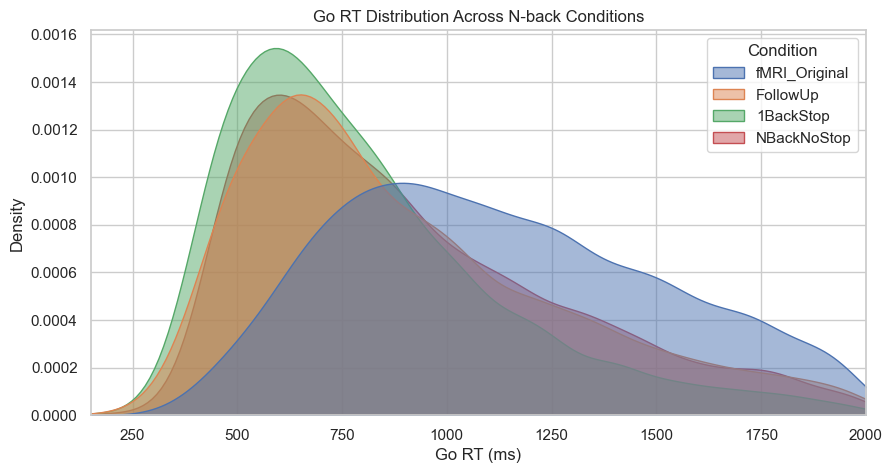

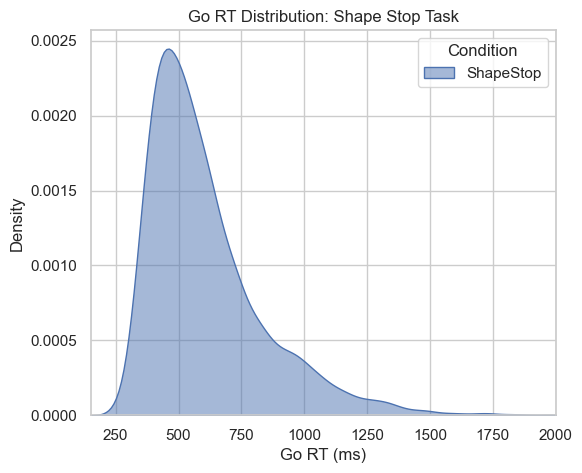

In [4]:
#-----------------------------------------
# Go RT Distribution Across N-back Conditions
#-----------------------------------------
##1. Prepare data for Go RTs
# ---------------------------
rt_list = []

for task, info in files_info.items():
    df = pd.read_excel(info["file"])
    
    # Clean subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    # Only include tasks with a stop/go column for Go RT selection
    if info.get("stop_go_col") is not None:
        # Filter Go trials and realistic RTs
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df = df[df[info["stop_go_col"]] == info["go_code"]]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])
    else:
        # For tasks with no stop/go (ShapeStop), include all RTs within range
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])

rt_df = pd.concat(rt_list, ignore_index=True)

# ---------------------------
# 2. Split into N-back vs ShapeStop
# ---------------------------
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]
shape_task = ["ShapeStop"]

rt_nback = rt_df[rt_df["Condition"].isin(nback_tasks)]
rt_shape = rt_df[rt_df["Condition"].isin(shape_task)]

# ---------------------------
# 3. Plot Go RT distributions
# ---------------------------
sns.set(style="whitegrid")

# N-back panel
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=rt_nback, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution Across N-back Conditions")
plt.show()

# ShapeStop panel
plt.figure(figsize=(6,5))
sns.kdeplot(
    data=rt_shape, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution: Shape Stop Task")
plt.show()



/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Task: fMRI_Original   | Subjects: 30  | Mean Acc: 85.36%


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Task: FollowUp        | Subjects: 23  | Mean Acc: 81.74%


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Task: 1BackStop       | Subjects: 23  | Mean Acc: 90.91%


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Task: NBackNoStop     | Subjects: 23  | Mean Acc: 89.92%
Task: ShapeStop       | Subjects: 23  | Mean Acc: 97.81%


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_50464/2343130533.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_acc_df, x='Condition', y='acc', palette='pastel')


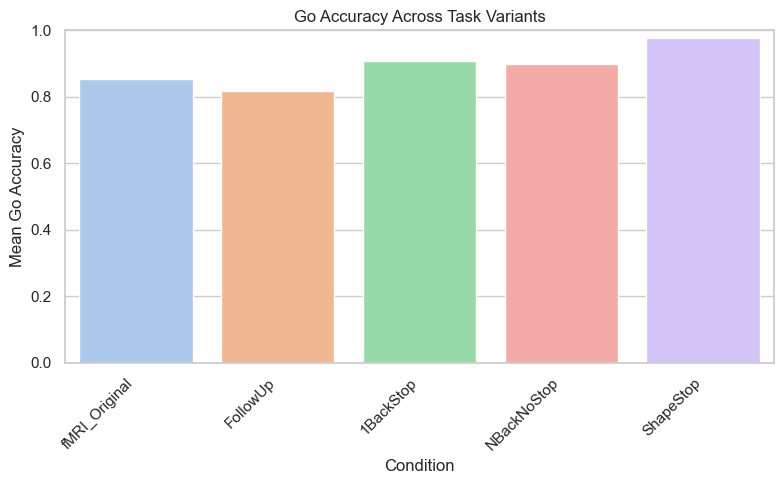

In [5]:
#-----------------------------------------
# Go Accuracy Across Task Variants
#-----------------------------------------
acc_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace

    # Standardize subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)

    # Filter Go trials if stop/go column exists
    if info.get('stop_go_col') is not None:
        go_df = df[df[info['stop_go_col']] == info['go_code']].copy()
    else:
        go_df = df.copy()  # everything is Go

    # Handle Go accuracy
    go_acc_col = info.get('go_acc')
    if go_acc_col is not None and go_acc_col in df.columns:
        go_df['acc'] = go_df[go_acc_col]
    else:
        # If no go_acc, use adaptive_acc if available
        if 'adaptive_acc' in df.columns:
            go_df['acc'] = go_df['adaptive_acc']
        else:
            # If no accuracy data, set as NaN
            go_df['acc'] = pd.Series([None] * len(go_df))

    # Compute mean accuracy per subject
    mean_acc = go_df.groupby('subject')['acc'].mean().reset_index()
    mean_acc['Condition'] = task
    
    task_avg = mean_acc['acc'].mean()
    print(f"Task: {task:<15} | Subjects: {len(mean_acc):<3} | Mean Acc: {task_avg:.2%}")
    #

    acc_list.append(mean_acc)

# Combine all tasks
acc_df = pd.concat(acc_list, ignore_index=True)

# Compute mean accuracy per condition, keeping NaN values if necessary
mean_acc_df = acc_df.groupby('Condition')['acc'].mean().reset_index()

# Optional: order conditions
condition_order = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop", "ShapeStop"]
mean_acc_df['Condition'] = pd.Categorical(mean_acc_df['Condition'], categories=condition_order, ordered=True)
mean_acc_df = mean_acc_df.sort_values('Condition')

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=mean_acc_df, x='Condition', y='acc', palette='pastel')
plt.ylim(0,1)
plt.ylabel('Mean Go Accuracy')
plt.title('Go Accuracy Across Task Variants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


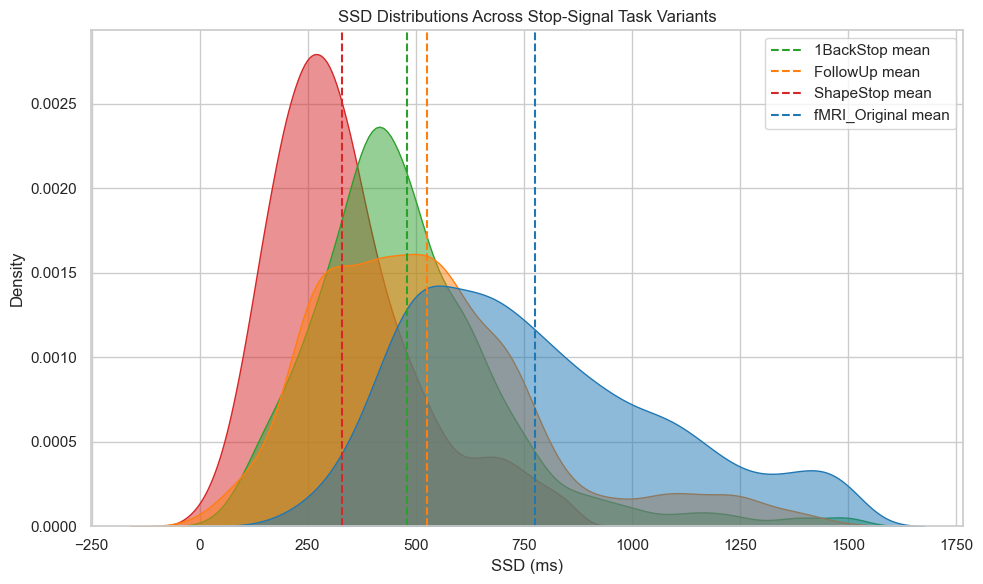

In [6]:
#-----------------------------------------
# SSD Distributions Across Stop-Signal Task Variants
# ---------------------------
# 1. Gather SSDs from all tasks
# ---------------------------
ssd_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove any weird spaces

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # Only include trials that have SSD (skip tasks without stop signals)
    if info.get('ssd_col') is not None:
        df = df[df[info['stop_go_col']] == info['stop_code']]  # only Stop trials
        df['Condition'] = task
        df['SSD'] = df[info['ssd_col']]
        ssd_list.append(df[['subject', 'Condition', 'SSD']])

# Combine all tasks
ssd_df = pd.concat(ssd_list, ignore_index=True)

# ---------------------------
# 2. Plot SSD distributions
# ---------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# Define colors to match conditions
conditions = ssd_df['Condition'].unique()
palette = sns.color_palette("tab10", n_colors=len(conditions))
color_map = dict(zip(conditions, palette))

# KDE per task
sns.kdeplot(
    data=ssd_df,
    x='SSD',
    hue='Condition',
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette=color_map
)

# Overlay mean SSD as vertical lines with matching colors
mean_ssd = ssd_df.groupby('Condition')['SSD'].mean()
for cond, mean_val in mean_ssd.items():
    plt.axvline(mean_val, linestyle='--', color=color_map[cond], label=f'{cond} mean')

plt.xlabel("SSD (ms)")
plt.ylabel("Density")
plt.title("SSD Distributions Across Stop-Signal Task Variants")
plt.legend()
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_50464/458669696.py:37: Fut

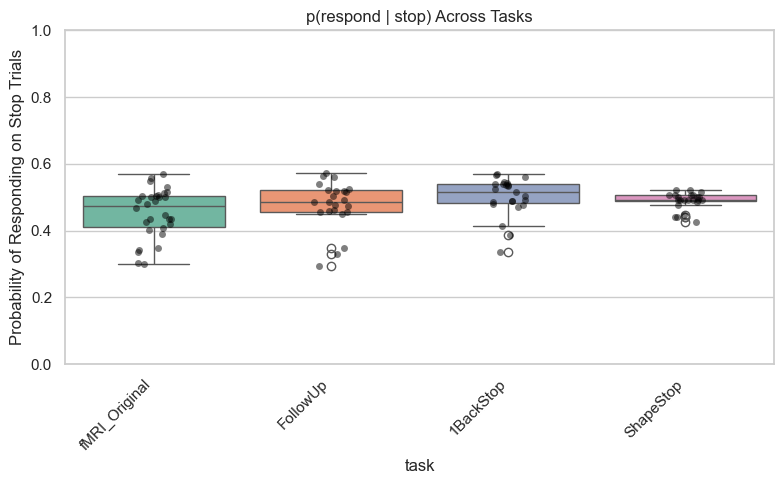

In [7]:

# ---------------------------
# Probability of responding on stop trials
# ---------------------------

# List to collect stop trial performance
stop_prob_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # clean column names

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # Only process tasks with stop trials
    if info.get('stop_go_col') is not None:
        # Identify stop trials
        stop_trials = df[df[info['stop_go_col']] == info['stop_code']].copy()
        
        # Probability of responding on stop trial: 1 = responded, 0 = successfully inhibited
        # If StopAcc column is 1 = successful stop, 0 = failed stop
        # Then responding = 1 - StopAcc
        stop_trials['responded'] = 1 - stop_trials[info['stop_acc_col']]

        # Compute mean per subject
        subj_mean = stop_trials.groupby('subject')['responded'].mean().reset_index()
        subj_mean['task'] = task
        stop_prob_list.append(subj_mean)

# Combine all tasks
stop_prob_df = pd.concat(stop_prob_list, ignore_index=True)

# ---------------------------
# Plot probability of responding given a stop signal
# ---------------------------
plt.figure(figsize=(8,5))
sns.boxplot(data=stop_prob_df, x='task', y='responded', palette="Set2")
sns.stripplot(data=stop_prob_df, x='task', y='responded', color='black', alpha=0.5, jitter=True)
plt.ylabel("Probability of Responding on Stop Trials")
plt.ylim(0,1)
plt.title("p(respond | stop) Across Tasks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Data loaded successfully. Proceeding to Cohort Identification...
Condition column repaired. You can now run the plots.


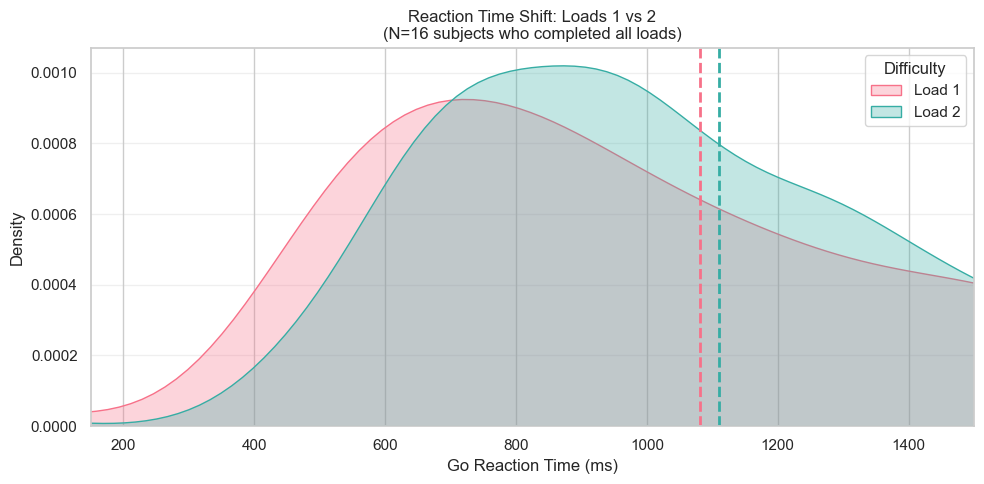

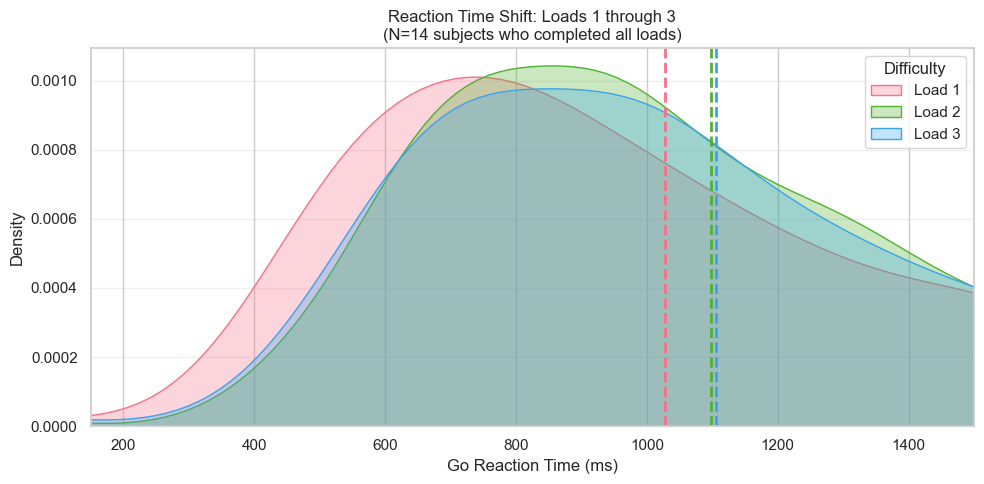

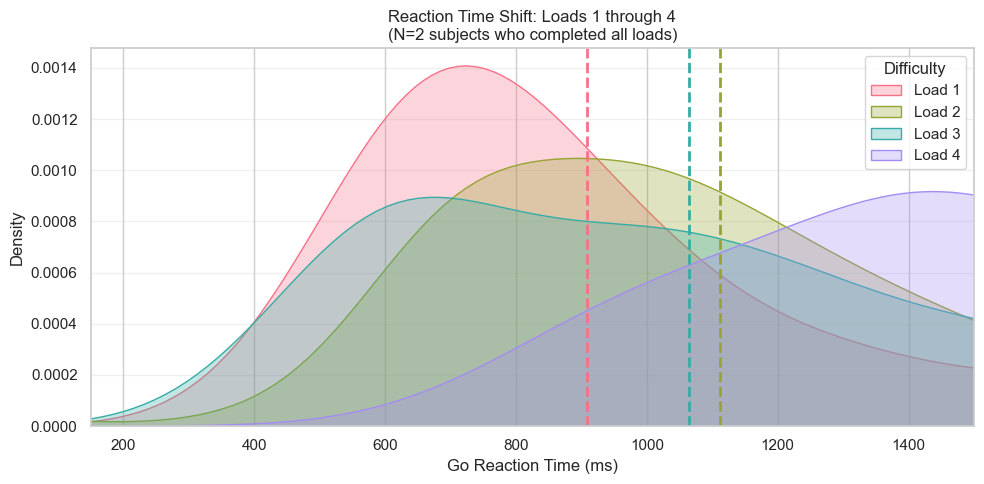

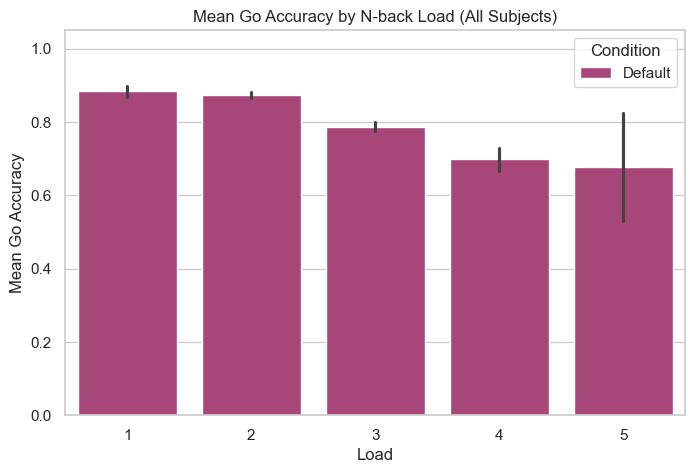

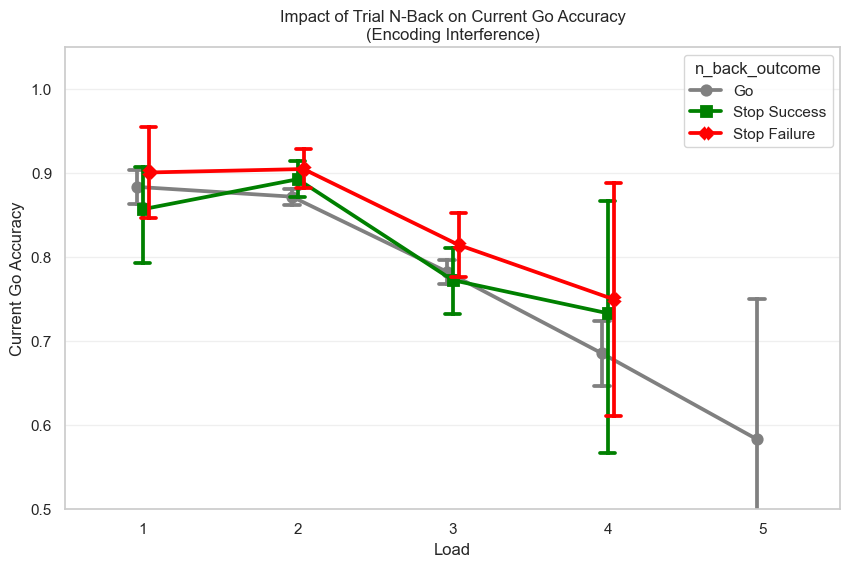

In [8]:
# ---------------------------
# Reaction times by load density plots, mean go accuracy by n-back load, 
# and impact of trial n-back on go accuracy (Encoding Interference)
# ---------------------------

# ---------------------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 1. DATA LOADING & CLEANING
# ---------------------------------------------------------
load_tasks = ["fMRI_Original", "FollowUp"]
all_go_trials = []
all_history_trials = [] 

for task in load_tasks:
    if task not in files_info: continue
    info = files_info[task]
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()
    
    # Standardize Columns
    sub_col = next((c for c in df.columns if 'subj' in c.lower()), None)
    df.rename(columns={sub_col: 'subject'}, inplace=True)
    tn_col = next((c for c in df.columns if 'trial' in c.lower() and 'num' in c.lower()), None)
    if tn_col: df.rename(columns={tn_col: 'TrialNum'}, inplace=True)
    load_col = next((c for c in df.columns if c.lower() == 'load'), None)
    if load_col: df['Load'] = df[load_col]

    # --- NEW: Identify the Trial Type Column Dynamically ---
    # This prevents the KeyError by checking which name this specific file uses
    trial_type_col = None
    if 'NoStop1StopSuccess2StopFail3' in df.columns:
        trial_type_col = 'NoStop1StopSuccess2StopFail3'
        outcome_map = {1: 'Go', 2: 'Stop Success', 3: 'Stop Failure'}
        go_val = 1
    elif 'stop_trial_type' in df.columns:
        trial_type_col = 'stop_trial_type'
        outcome_map = {'go': 'Go', 'succ': 'Stop Success', 'fail': 'Stop Failure'}
        go_val = 'go'

    if trial_type_col:
        # Create standardized current_outcome column
        df['current_outcome'] = df[trial_type_col].map(outcome_map)
        
        # Standardize the 'Triplets' column so the plotting function works later
        # We convert everything to 1, 2, 3 format for the final function
        reverse_map = {'Go': 1, 'Stop Success': 2, 'Stop Failure': 3}
        df['NoStop1StopSuccess2StopFail3'] = df['current_outcome'].map(reverse_map)
        
        # Sort and shift history
        df = df.sort_values(['subject', 'TrialNum'])
        df['n_back_outcome'] = df.groupby('subject')['current_outcome'].shift(1)
        
        # Store for full history
        all_history_trials.append(df.copy())

        # Handle Accuracy & Create Go-only version
        acc_col = next((c for c in df.columns if 'go' in c.lower() and 'acc' in c.lower()), None)
        if acc_col:
            df['acc'] = pd.to_numeric(df[acc_col], errors='coerce')
        
        # Apply the mask safely using the go_val we found above
        go_mask = (df[trial_type_col] == go_val)
        go_df = df[go_mask].copy().dropna(subset=['acc'])
        
        if not go_df.empty:
            if go_df['acc'].mean() > 1:
                go_df['acc'] = go_df['acc'].map({1: 1, 2: 0})
            all_go_trials.append(go_df)

# Combine datasets
load_df = pd.concat(all_go_trials, ignore_index=True)
full_history_df = pd.concat(all_history_trials, ignore_index=True)

print("Data loaded successfully. Proceeding to Cohort Identification...")
# ---------------------------------------------------------
# 2. COHORT IDENTIFICATION (Balanced Subjects)
# ---------------------------------------------------------
subj_load_sets = load_df.groupby('subject')['Load'].unique().apply(set)

def get_balanced_cohort(all_data, required_loads):
    req_set = set(required_loads)
    mask = subj_load_sets.apply(lambda x: req_set.issubset(x))
    valid_subjects = subj_load_sets[mask].index
    return all_data[all_data['subject'].isin(valid_subjects) & all_data['Load'].isin(required_loads)]

# Subsets for Standard Plots
df_12   = get_balanced_cohort(load_df, [1, 2])
df_123  = get_balanced_cohort(load_df, [1, 2, 3])
df_1234 = get_balanced_cohort(load_df, [1, 2, 3, 4])

# Subsets for Triplet Plots (Includes Stop Trials)
df_12_full  = get_balanced_cohort(full_history_df, [1, 2])
df_123_full = get_balanced_cohort(full_history_df, [1, 2, 3])

# ---------------------------
# 3. PLOTTING
# ---------------------------
# --- REPAIR CONDITION COLUMN ---
# Ensure every row in load_df has a 'Condition' value. 
# If it's missing, we label it 'Unknown' so the plot doesn't crash.
if 'Condition' not in load_df.columns:
    load_df['Condition'] = 'Default'
else:
    load_df['Condition'] = load_df['Condition'].fillna('Unknown')

# Force Load to be an integer (helps with the x-axis alignment)
load_df['Load'] = pd.to_numeric(load_df['Load'], errors='coerce').fillna(0).astype(int)

print("Condition column repaired. You can now run the plots.")

# === PLOT 1: Go RT Distributions ===
def plot_cohort_dist(data, loads, title):
    if data.empty: return
    plt.figure(figsize=(10, 5))
    n_subj = data['subject'].nunique()
    colors = sns.color_palette("husl", len(loads))
    
    for i, load in enumerate(loads):
        subset = data[data['Load'] == load]
        sns.kdeplot(data=subset, x='RT', fill=True, alpha=0.3, color=colors[i], label=f"Load {load}")
        plt.axvline(subset['RT'].mean(), color=colors[i], linestyle='--', linewidth=2)
    
    plt.title(f"{title}\n(N={n_subj} subjects who completed all loads)")
    plt.xlabel("Go Reaction Time (ms)")
    plt.xlim(150, 1500)
    plt.legend(title="Difficulty")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_cohort_dist(df_12, [1, 2], "Reaction Time Shift: Loads 1 vs 2")
plot_cohort_dist(df_123, [1, 2, 3], "Reaction Time Shift: Loads 1 through 3")
plot_cohort_dist(df_1234, [1, 2, 3, 4], "Reaction Time Shift: Loads 1 through 4")

# === PLOT 2: Mean Go Accuracy by Load ===
plt.figure(figsize=(8,5))
sns.barplot(data=load_df, x='Load', y='acc', hue='Condition', palette='magma')
plt.ylabel("Mean Go Accuracy")
plt.ylim(0, 1.05)
plt.title("Mean Go Accuracy by N-back Load (All Subjects)")
plt.show()

# === PLOT 3: Encoding Interference (The "Fixed" Plot) ===
plt.figure(figsize=(10,6))
sns.pointplot(
    data=load_df, x='Load', y='acc', hue='n_back_outcome',
    hue_order=['Go', 'Stop Success', 'Stop Failure'],
    palette={'Go': 'gray', 'Stop Success': 'green', 'Stop Failure': 'red'},
    dodge=True, markers=['o', 's', 'X'], capsize=0.1
)
plt.title("Impact of Trial N-Back on Current Go Accuracy\n(Encoding Interference)")
plt.ylabel("Current Go Accuracy")
plt.ylim(0.5, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.show()

/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_50464/3470353204.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_paired, x='subject', y='acc', hue='Load', palette='pastel', ci=None)


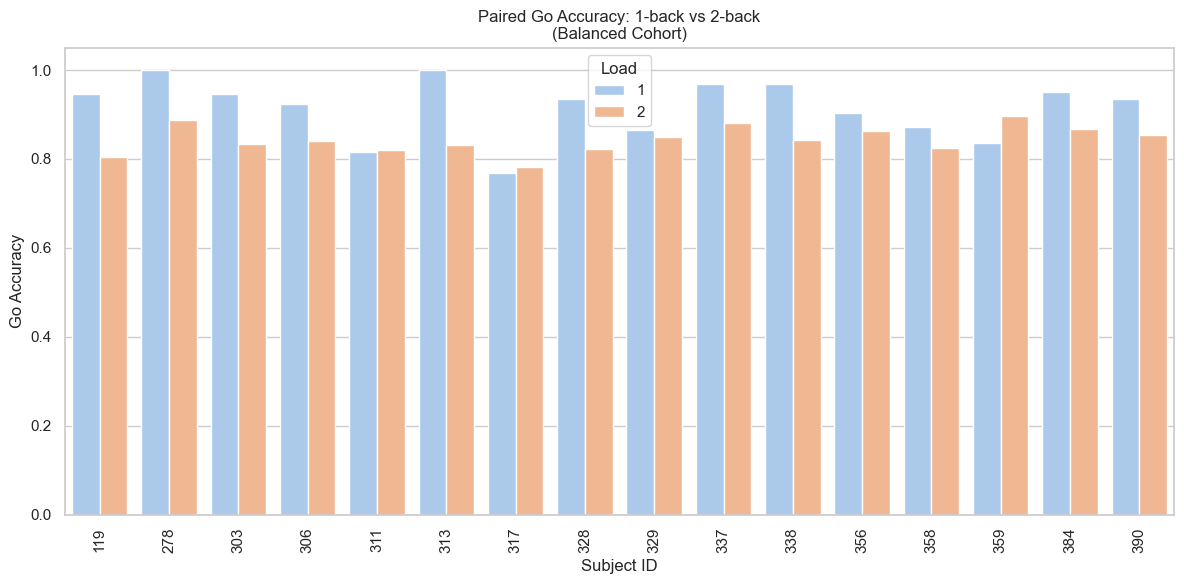

/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_50464/3470353204.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.lineplot(data=load_df, x='Load', y='acc', marker='o', color='blue', ci=68)


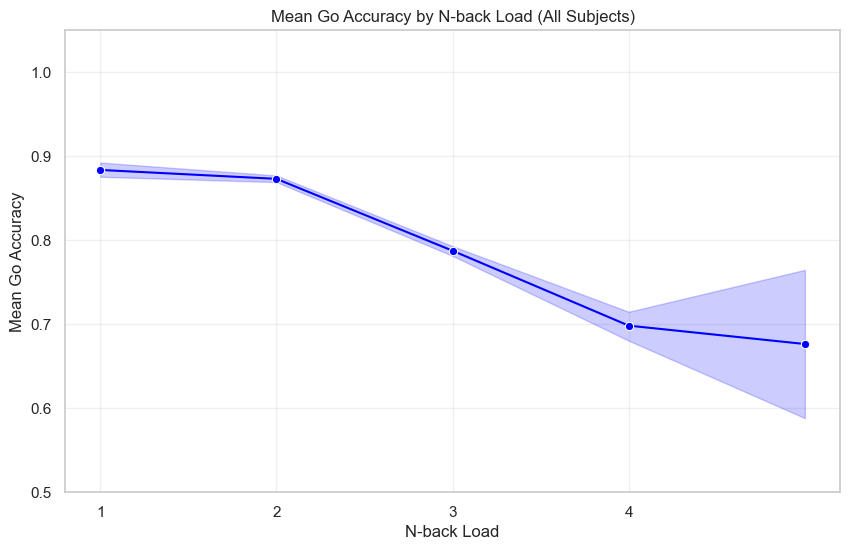

In [9]:
# ---------------------------------------------------------
# Go accuracy by load
# ---------------------------------------------------------

# 1. Use existing function to get the data of subjects who only completed both loads 1 and 2
df_paired = get_balanced_cohort(load_df, [1, 2])

# 2. Plot  directly
plt.figure(figsize=(12, 6))
sns.barplot(data=df_paired, x='subject', y='acc', hue='Load', palette='pastel', ci=None)

plt.xlabel('Subject ID')
plt.ylabel('Go Accuracy')
plt.title('Paired Go Accuracy: 1-back vs 2-back\n(Balanced Cohort)')
plt.xticks(rotation=90)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

# sns.lineplot calculates the mean AND the error bars (ci=68 is approx 1 SEM)
sns.lineplot(data=load_df, x='Load', y='acc', marker='o', color='blue', ci=68)

plt.xlabel('N-back Load')
plt.ylabel('Mean Go Accuracy')
plt.title('Mean Go Accuracy by N-back Load (All Subjects)')
plt.xticks([1, 2, 3, 4])
plt.ylim(0.5, 1.05) # Zoomed in to see the decline better
plt.grid(True, alpha=0.3)
plt.show()

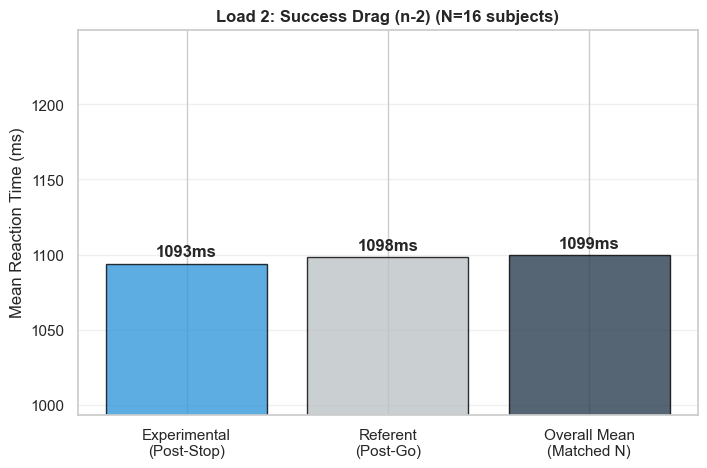

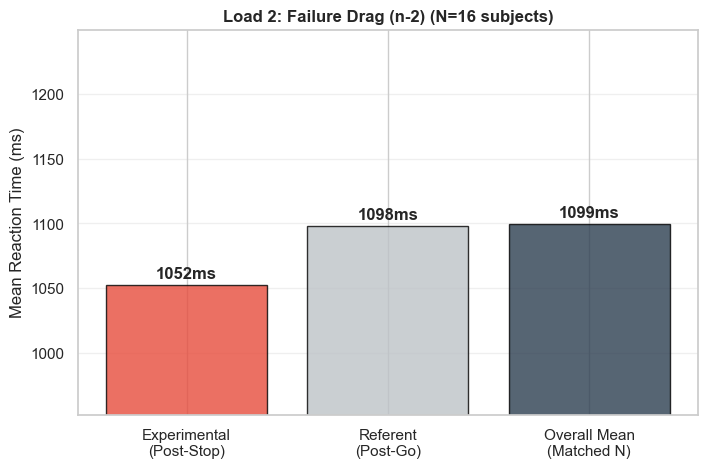

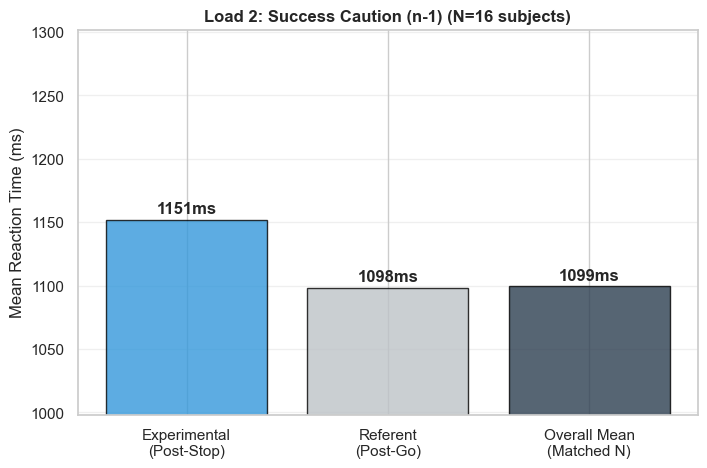

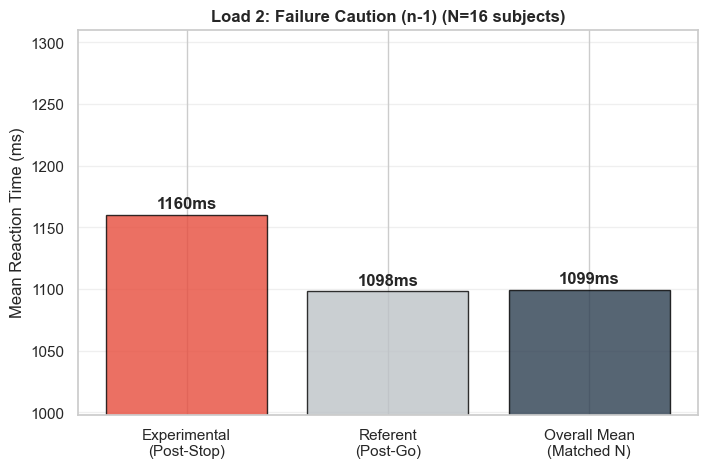

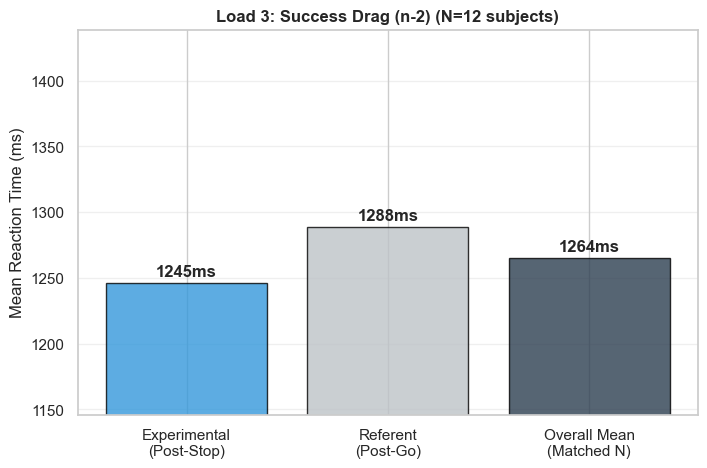

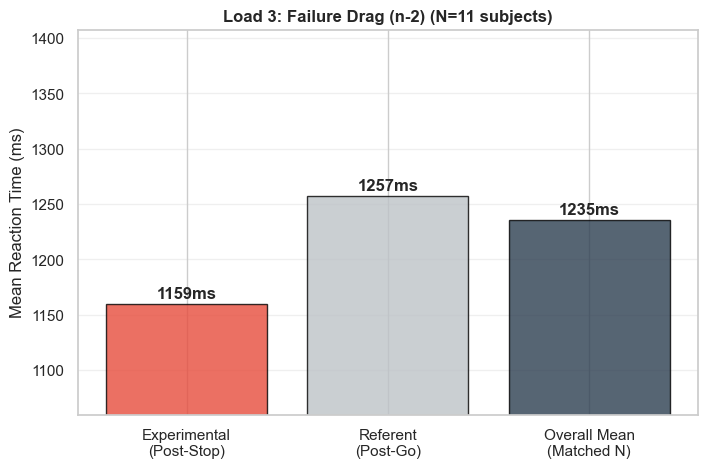

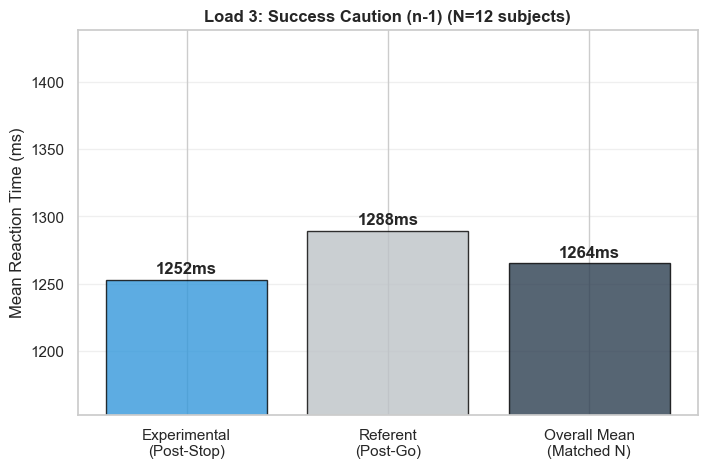

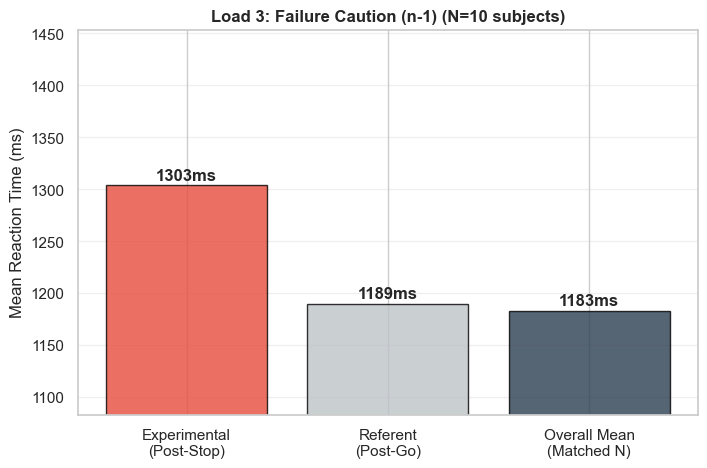

In [15]:
def create_triplet_analysis(full_df, load_val):
    # --- 1. PREP THE SEQUENCES ---
    df = full_df.copy().sort_values(['subject', 'TrialNum'])
    
    # Identify history
    df['n1_type'] = df.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(1)
    df['n2_type'] = df.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(2)
    
    # --- 2. ISOLATE TARGETS WITH STREAK ANCHORING ---
    # Global: All correct Go trials for this load
    all_targets = df[(df['NoStop1StopSuccess2StopFail3'] == 1) & (df['RT'] > 0)].copy()
    
    # Drag (n-2) requires n-1 to be a Go trial
    drag_targets = all_targets[all_targets['n1_type'] == 1].copy()
    
    # Caution (n-1) requires n-2 to be a Go trial
    caus_targets = all_targets[all_targets['n2_type'] == 1].copy()

    # --- 3. AGGREGATE ---
    drag_stats = drag_targets.groupby(['subject', 'n2_type'])['RT'].mean().unstack()
    caus_stats = caus_targets.groupby(['subject', 'n1_type'])['RT'].mean().unstack()
    
    # Crucial: Overall Mean baseline for this subject/load
    overall_stats = all_targets.groupby('subject')['RT'].mean()
    
    results = []

    # Helper to build result dictionaries
    def add_result(stats_df, exp_type, ref_type, label):
        valid = stats_df[[ref_type, exp_type]].dropna()
        if not valid.empty:
            results.append({
                'title': f'Load {load_val}: {label}',
                'exp': valid[exp_type].mean(),
                'ref': valid[ref_type].mean(),
                'ovr': overall_stats.loc[valid.index].mean(), # Re-attaching overall_stats here
                'n': len(valid)
            })

    # --- 4. BUILD THE 4 PLOT DATASETS ---
    # Drag (n-2)
    add_result(drag_stats, 2.0, 1.0, "Success Drag (n-2)")
    add_result(drag_stats, 3.0, 1.0, "Failure Drag (n-2)")
    
    # Caution (n-1)
    add_result(caus_stats, 2.0, 1.0, "Success Caution (n-1)")
    add_result(caus_stats, 3.0, 1.0, "Failure Caution (n-1)")

    return results

# --- EXECUTION & VISUALIZATION ---
for df_set, load in [(df_12_full, 2), (df_123_full, 3)]:
    triplets = create_triplet_analysis(df_set[df_set['Load'] == load], load)
    
    for t in triplets:
        plt.figure(figsize=(8, 5))
        labels = ['Experimental\n(Post-Stop)', 'Referent\n(Post-Go)', 'Overall Mean\n(Matched N)']
        values = [t['exp'], t['ref'], t['ovr']]
        
        # Color coding: Red for Failure-related, Blue for Success-related
        color = '#e74c3c' if 'Failure' in t['title'] else '#3498db'
        bars = plt.bar(labels, values, color=[color, '#bdc3c7', '#2c3e50'], edgecolor='black', alpha=0.8)
        
        # Add data labels
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f'{int(yval)}ms', ha='center', fontweight='bold')

        plt.title(f"{t['title']} (N={t['n']} subjects)", fontweight='bold')
        plt.ylabel("Mean Reaction Time (ms)")
        plt.ylim(min(values)-100, max(values)+150)
        plt.grid(axis='y', alpha=0.3)
        plt.show()

In [24]:
# --- INCLUSIVE AUDIT: New 1-trial rule ---
# Purpose: Calculates the "Average of the Differences" (Subject-level shift)
# Logic: Ensures we compare Stop trials to a clean Go-Go-Go baseline.

def run_inclusive_audit(df_full, load_val):
    # 1. Get data for this Load and sort by time (TrialNum)
    df = df_full[df_full['Load'] == load_val].copy().sort_values(['subject', 'TrialNum'])
    df['is_correct_go'] = (df['NoStop1StopSuccess2StopFail3'] == 1) & (df['RT'] > 0)
    
    # 2. "Shift" identifies what happened 1 and 2 steps ago
    df['n1_type'] = df.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(1)
    df['n2_type'] = df.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(2)
    df['n1_corr'] = df.groupby('subject')['is_correct_go'].shift(1) # Correct Go @ n-1
    df['n2_corr'] = df.groupby('subject')['is_correct_go'].shift(2) # Correct Go @ n-2

    # 3. DRAG AUDIT (n-2): "The Alerting Effect"
    # FILTER: Current trial is Go, but trial n-1 MUST be a Correct Go (The Anchor).
    # This isolates the effect of the Stop trial from two steps back.
    drag = df[(df['is_correct_go']) & (df['n1_type'] == 1) & (df['n1_corr'])].groupby(['subject', 'n2_type'])['RT'].agg(['mean', 'count']).unstack()
    drag.columns = [f"{c[0]}_{int(float(c[1]))}" for c in drag.columns if pd.notnull(c[1])]
    
    # SUCCESS/FAILURE DRAG: Drop subjects who don't have BOTH a baseline and an experimental trial.
    succ_drag = drag[['mean_1', 'mean_2']].dropna() 
    fail_drag = drag[['mean_1', 'mean_3']].dropna() 

    # 4. CAUTION AUDIT (n-1): "Post-Stop Slowing"
    # FILTER: Current trial is Go, but trial n-2 MUST be a Correct Go (The Anchor).
    # This ensures the subject was in a 'clean streak' before the Stop happened.
    caus = df[(df['is_correct_go']) & (df['n2_type'] == 1) & (df['n2_corr'])].groupby(['subject', 'n1_type'])['RT'].agg(['mean', 'count']).unstack()
    caus.columns = [f"{c[0]}_{int(float(c[1]))}" for c in caus.columns if pd.notnull(c[1])]
    
    succ_caus = caus[['mean_1', 'mean_2']].dropna()
    fail_caus = caus[['mean_1', 'mean_3']].dropna()

    # 5. Checks N-counts
    print(f"--- LOAD {load_val} INCLUSIVE AUDIT ---")
    print(f"Success Drag N:    {len(succ_drag)}")
    print(f"Failure Drag N:    {len(fail_drag)}")
    print(f"Success Caution N: {len(succ_caus)}")
    print(f"Failure Caution N: {len(fail_caus)}")
    print("-" * 30)
    
    # 6. RESULTS: (Experimental RT minus Referent RT)
    # Positive result (+) = Slowdown (Caution)
    # Negative result (-) = Speedup (Drag Paradox/Alerting)
    return {
        'SD': (succ_drag['mean_2'] - succ_drag['mean_1']).mean(), # Success Drag
        'FD': (fail_drag['mean_3'] - fail_drag['mean_1']).mean(), # Failure Drag
        'SC': (succ_caus['mean_2'] - succ_caus['mean_1']).mean(), # Success Caution
        'FC': (fail_caus['mean_3'] - fail_caus['mean_1']).mean()  # Failure Caution
    }

# Run and Display
l2_results = run_inclusive_audit(df_12_full, 2)
l3_results = run_inclusive_audit(df_123_full, 3)

print(f"\nFinal Caution (Failure) Load 3: {l3_results['SD']:.1f} ms")
print(f"\nFinal Caution (Failure) Load 3: {l3_results['FD']:.1f} ms")
print(f"\nFinal Caution (Failure) Load 3: {l3_results['SC']:.1f} ms")
print(f"\nFinal Caution (Failure) Load 3: {l3_results['FC']:.1f} ms")

--- LOAD 2 INCLUSIVE AUDIT ---
Success Drag N:    16
Failure Drag N:    16
Success Caution N: 16
Failure Caution N: 16
------------------------------
--- LOAD 3 INCLUSIVE AUDIT ---
Success Drag N:    12
Failure Drag N:    11
Success Caution N: 12
Failure Caution N: 10
------------------------------

Final Caution (Failure) Load 3: -34.8 ms

Final Caution (Failure) Load 3: -89.9 ms

Final Caution (Failure) Load 3: -16.2 ms

Final Caution (Failure) Load 3: 109.1 ms
